In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [47]:
import warnings
warnings.filterwarnings('ignore')

# Part 1: Data Preparation and Exploration

In [48]:
#Load Dataset
df = pd.read_csv("exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [50]:
df.isnull().sum()

date       0
Ex_rate    0
dtype: int64

In [51]:
# Convert Date Column & Set Index
#(Replace 'Date' with the actual date column name if it is different.)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


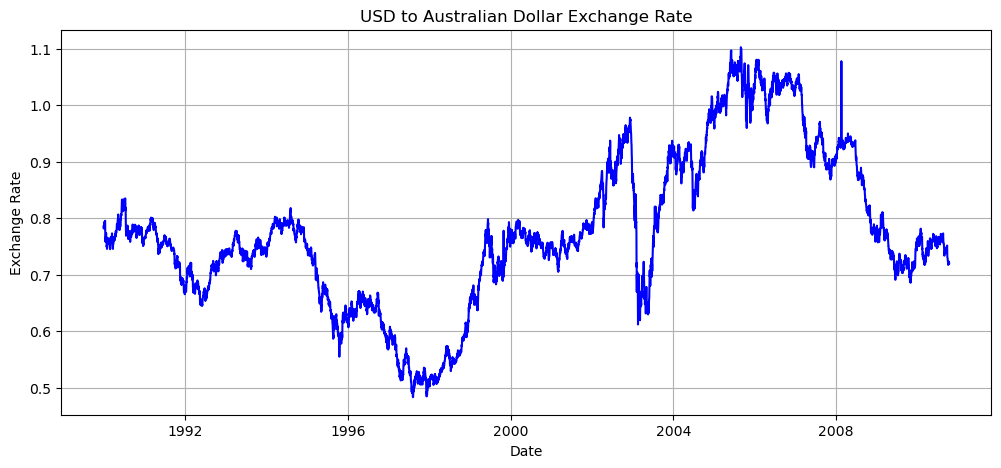

In [52]:
#Time Series Plot 
plt.figure(figsize=(12,5))
plt.plot(df.iloc[:,0], color='blue')

plt.title('USD to Australian Dollar Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')

plt.grid(True)
plt.show()

In [53]:
#Handle Missing Values
df.fillna(method='ffill', inplace=True)
df.isnull().sum()

Ex_rate    0
dtype: int64

In [54]:
#Train-Test Split
#We'll use the last 20% of observations as the test set.
train_size = int(len(df)*0.80)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

Training Shape : (6070, 1)
Testing Shape  : (1518, 1)


# Part-2: Model Building – ARIMA

In [55]:
# Check Stationarity (ADF Test)from statsmodels.tsa.stattools import adfuller

result = adfuller(train.iloc[:,0])

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -0.9808550190079159
p-value : 0.7601827946371973

Critical Values:
1%: -3.431429371666765
5%: -2.8620169839390432
10%: -2.5670238959668166


In [56]:
#Interpretation
if result[1] <= 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

The time series is non-stationary.


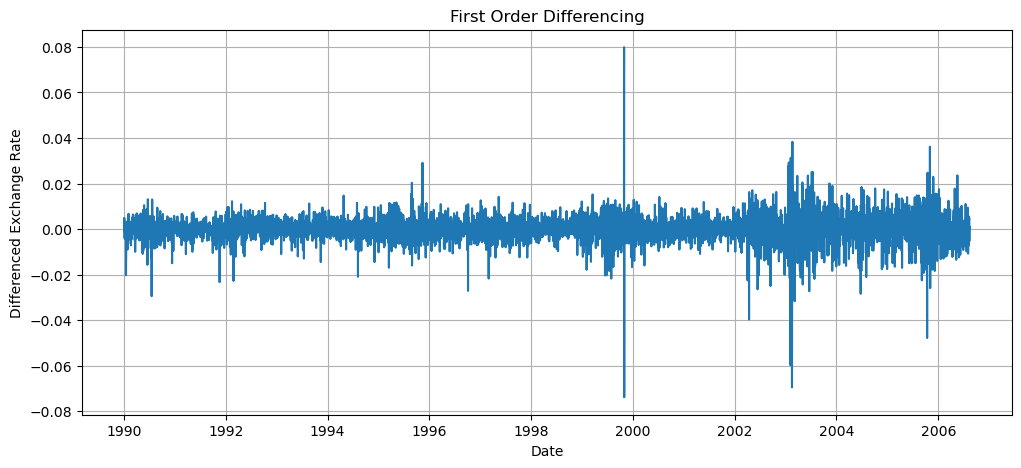

In [57]:
#Non-Stationary, Apply First Differencing
train_diff = train.iloc[:,0].diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(train_diff)
plt.title("First Order Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced Exchange Rate")
plt.grid(True)
plt.show()

In [58]:
# Check Stationarity Again
result_diff = adfuller(train_diff)

print("ADF Statistic :", result_diff[0])
print("p-value :", result_diff[1]) #If p-value < 0.05, then d = 1 is appropriate.

ADF Statistic : -27.336001463801466
p-value : 0.0


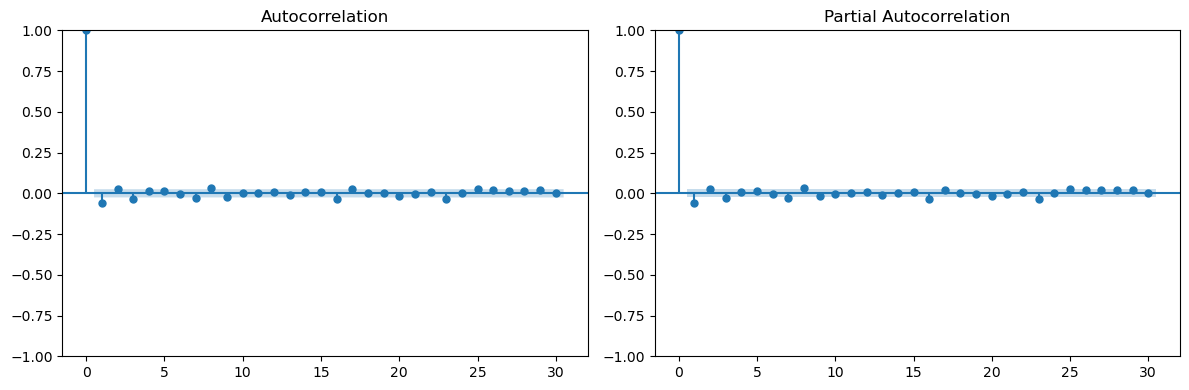

In [59]:
#Plotting ACF and PACF
fig, axes = plt.subplots(1,2, figsize=(12,4))

plot_acf(train_diff, ax=axes[0], lags=30)
plot_pacf(train_diff, ax=axes[1], lags=30)

plt.tight_layout()
plt.show()

## ARIMA Model Building

In [60]:
from pmdarima import auto_arima
from pmdarima.model_selection import train_test_split

In [61]:
#Running the auto_arima
auto_model = auto_arima(y=train, max_p=5, start_q=0,
                           max_q=5,  trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-45425.953, Time=1.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-45404.538, Time=1.25 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-45424.276, Time=1.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-45423.258, Time=1.91 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-45406.255, Time=0.40 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-45430.006, Time=3.06 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-45428.403, Time=2.74 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-45427.912, Time=1.65 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-45398.539, Time=1.81 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-45426.433, Time=1.65 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-45431.682, Time=1.33 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-45427.648, Time=0.51 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=-45430.083, Time=1.08 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-45429.587, Time=1.02 sec
 ARIM

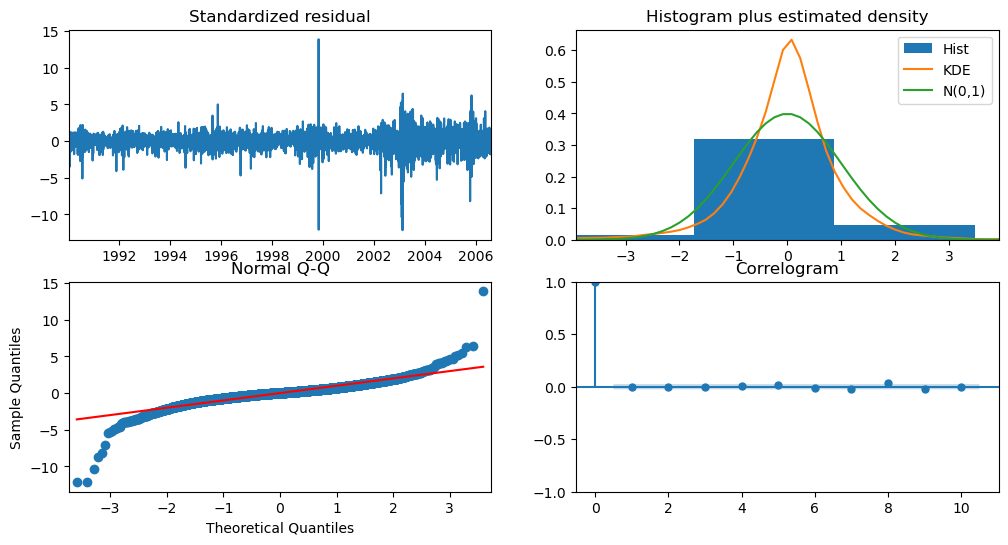

In [62]:
auto_model.plot_diagnostics(figsize=(12,6))
plt.show()

In [63]:
# Build ARIMA Model
arima_model = ARIMA(train.iloc[:,0], order=(3,1,0))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(3, 1, 0)   Log Likelihood               22719.841
Date:                Fri, 24 Jul 2026   AIC                         -45431.682
Time:                        20:18:39   BIC                         -45404.838
Sample:                    01-01-1990   HQIC                        -45422.365
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0574      0.005    -11.248      0.000      -0.067      -0.047
ar.L2          0.0228      0.007      3.417      0.001       0.010       0.036
ar.L3         -0.0315      0.007     -4.661      0.0

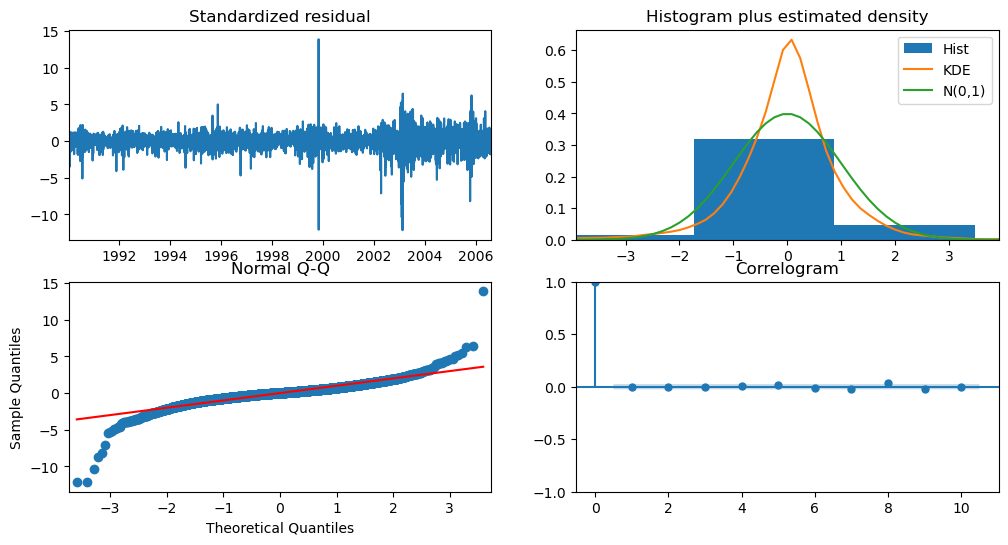

In [64]:
auto_model.plot_diagnostics(figsize=(12,6))
plt.show()

In [65]:
# Forecast for the test period
arima_forecast  = arima_fit.forecast(len(test))
arima_forecast.head()

2006-08-15    1.023732
2006-08-16    1.023692
2006-08-17    1.023694
2006-08-18    1.023687
2006-08-19    1.023689
Freq: D, Name: predicted_mean, dtype: float64

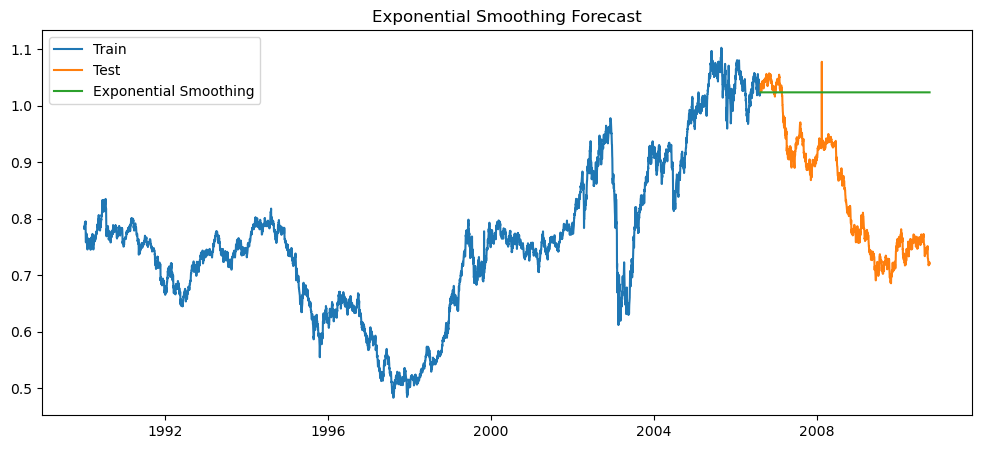

In [66]:
#Forecast Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train.iloc[:,0], label='Train')
plt.plot(test.index, test.iloc[:,0], label='Test')
plt.plot(test.index, arima_forecast, label='Exponential Smoothing')
plt.title("Exponential Smoothing Forecast")
plt.legend()
plt.show()


## Exponential Smoothing

In [67]:
#Build Model
exp_model = ExponentialSmoothing(
    train.iloc[:,0],
    trend='add',
    seasonal=None
)

exp_fit = exp_model.fit()

In [68]:
#Forecast
exp_forecast = exp_fit.forecast(len(test))
exp_forecast.head()

2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
Freq: D, dtype: float64

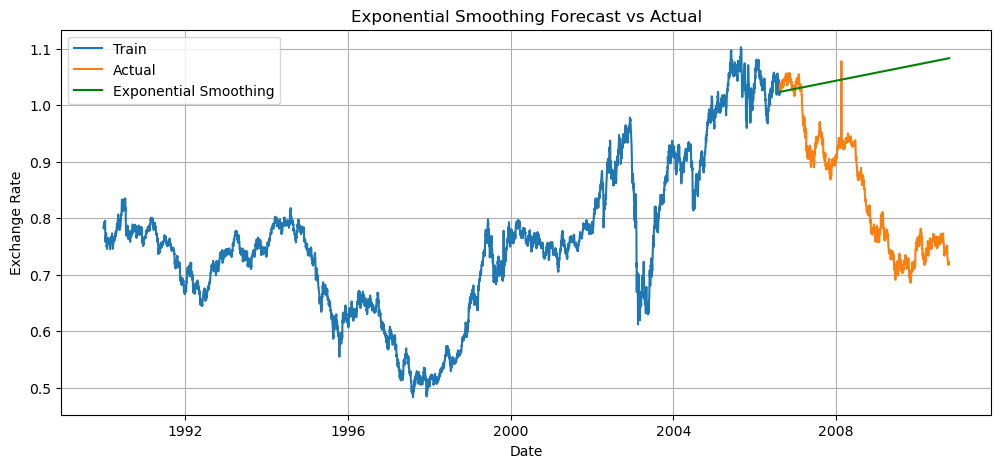

In [69]:
#plot Forecast
plt.figure(figsize=(12,5))
plt.plot(train.index, train.iloc[:,0], label='Train')
plt.plot(test.index, test.iloc[:,0], label='Actual')
plt.plot(test.index, exp_forecast, label='Exponential Smoothing', color='green')

plt.title("Exponential Smoothing Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

# Part 3: Evaluation and Comparison

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [71]:
# Error Metrics
def mape(actual, pred):
    return np.mean(np.abs((actual-pred)/actual))*100

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = mape(test.values, arima_forecast.values)

exp_mae = mean_absolute_error(test, exp_forecast)
exp_rmse = np.sqrt(mean_squared_error(test, exp_forecast))
exp_mape = mape(test.values, exp_forecast.values)

In [72]:
# Comparison Table
comparison = pd.DataFrame({
    'Model':['ARIMA','Exponential Smoothing'],
    'MAE':[arima_mae,exp_mae],
    'RMSE':[arima_rmse,exp_rmse],
    'MAPE':[arima_mape,exp_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177750,0.205482,22.803073
1,Exponential Smoothing,0.206596,0.239104,26.035287


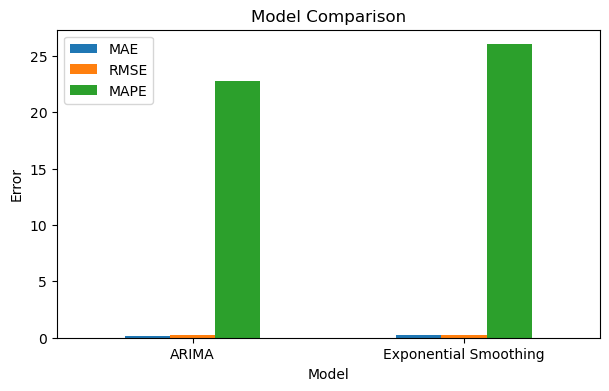

In [73]:
#Comparison Plot
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(7,4)
)

plt.title("Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)

plt.show()

#### Model Comparison:
ARIMA outperformed Exponential Smoothing by achieving lower MAE (0.1778), RMSE (0.2055), and MAPE (22.80%), indicating more accurate exchange rate forecasts.
ARIMA effectively captured the temporal dependencies and fluctuations in the exchange rate data, whereas Exponential Smoothing produced comparatively larger forecasting errors.
Based on the evaluation metrics, ARIMA is the preferred forecasting model for this exchange rate dataset.

### Conclusion:
Historical exchange rates were successfully analyzed and forecasted using both ARIMA and Exponential Smoothing models.
Among the two models, ARIMA (3,1,0) delivered the best forecasting performance with the lowest MAE, RMSE, and MAPE values.
Therefore, ARIMA is recommended for forecasting exchange rates, as it provides higher accuracy and better models the non-stationary nature of financial time series.